
# Exploring Convolutional Layers Through Data and Experiments -- Tomas Espitia

In [13]:
%pip install torch torchvision pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\tomas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
from __future__ import annotations

from typing import Tuple, Dict
import os
import json
import tarfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


Dataset
Para el desarrollo de este trabajo se utiliza el dataset Fashion-MNIST, un conjunto de datos público ampliamente usado en tareas de clasificación de imágenes. Este dataset está compuesto por imágenes en escala de grises de 28 × 28 píxeles, distribuidas en 10 clases que representan diferentes tipos de prendas de vestir, como camisetas, pantalones, abrigos, sandalias, zapatillas y bolsos.

Fashion-MNIST es adecuado para el estudio de redes neuronales convolucionales debido a que las clases se diferencian principalmente por patrones espaciales locales, tales como bordes, contornos y texturas, los cuales pueden aparecer en distintas posiciones dentro de la imagen. Esto permite analizar el inductive bias introducido por las capas convolucionales, específicamente la conectividad local y la compartición de pesos, y comparar su desempeño frente a modelos totalmente conectados.

Los datos se cargan utilizando la librería torchvision.datasets.FashionMNIST, lo que garantiza la reproducibilidad del experimento y evita procesos manuales de descarga y preparación del conjunto de datos. Como etapa de preprocesamiento, se realiza la conversión de las imágenes a tensores y se aplica normalización, con el fin de estabilizar y mejorar el proceso de entrenamiento del modelo.

# 1. Dataset Exploration (EDA)

En esta sección se analiza la estructura del dataset Fashion-MNIST con el objetivo de comprender sus principales características antes de definir y diseñar las arquitecturas de la red neuronal. Para ello, se revisan aspectos como el tamaño del conjunto de datos, la distribución de las clases, la forma de las imágenes (dimensiones y número de canales), ejemplos representativos por clase y el preprocesamiento aplicado, específicamente la normalización.

Este análisis busca proporcionar una comprensión general de la naturaleza del problema de clasificación, sin entrar en un estudio estadístico exhaustivo, permitiendo así tomar decisiones informadas sobre el diseño y entrenamiento de los modelos de red neuronal.

In [15]:
class_names = [
    "T-shirt/top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Ankle boot"
]


In [19]:
#Nombre de las clase
#Vamos a explorar el Dataset
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize((0.2860,), (0.3530,)) 
])


In [ ]:
# Cargamos el dataset
train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


In [ ]:
# Miramos el tamañi que tiene nuestro dataset
print("Tamaño conjunto de entrenamiento:", len(train_dataset))
print("Tamaño conjunto de prueba:", len(test_dataset))


Tamaño conjunto de entrenamiento: 60000
Tamaño conjunto de prueba: 10000


In [22]:
#Aca vemos las dimensiones de las imagenes
image, label = train_dataset[0]
print("Dimensión de la imagen:", image.shape)
print("Etiqueta:", label, "-", class_names[label])


Dimensión de la imagen: torch.Size([1, 28, 28])
Etiqueta: 9 - Ankle boot


In [23]:
train_labels = pd.Series([y for _, y in train_dataset])
test_labels = pd.Series([y for _, y in test_dataset])

print("Distribución de clases (train):")
print(train_labels.value_counts().sort_index())

print("\nDistribución de clases (test):")
print(test_labels.value_counts().sort_index())


Distribución de clases (train):
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

Distribución de clases (test):
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


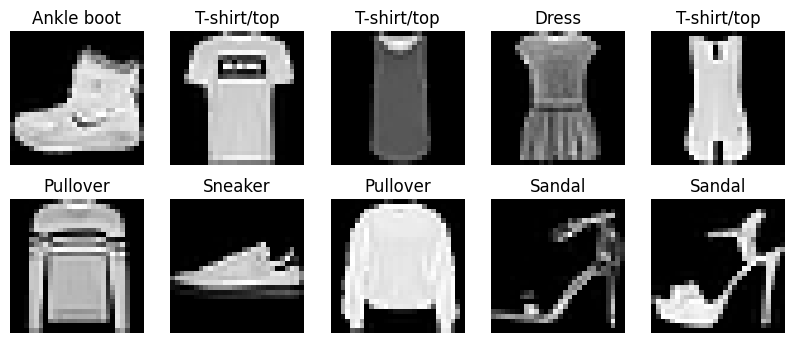

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    img, lbl = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[lbl])
    ax.axis("off")

plt.show()
